<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/numerical-programming-hw-06/numerical_programming_hw06_esc50_spectrogram_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Тема 6

## Перетворення Фурʼє, спектрограми та кластеризація звуків ESC-50

У роботі використовується набір даних **ESC-50**. Для аналізу вибрано два класи звуків: **dog** та **chirping_birds**.

Мета: побудувати спектрограми звукових сигналів, зменшити їх розмір за допомогою pooling, перетворити у вектори ознак та виконати кластеризацію методом `SpectralClustering`.

## 1. Імпорт бібліотек

In [11]:
import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
pimport_error = None
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.io import wavfile
    from sklearn.cluster import SpectralClustering
    from sklearn.metrics import adjusted_rand_score, confusion_matrix
    from sklearn.preprocessing import StandardScaler
except Exception as e:
    pimport_error = e
    raise

np.random.seed(42)
sns.set(style="whitegrid")

## 2. Завантаження набору даних ESC-50

Якщо датасет ще не завантажений у середовище Colab, він автоматично завантажується з офіційного GitHub-репозиторію ESC-50.

In [12]:
DATA_URL = "https://github.com/karolpiczak/ESC-50/archive/master.zip"
ZIP_PATH = Path("ESC-50-master.zip")
DATA_DIR = Path("ESC-50-master")

if not DATA_DIR.exists():
    print("Downloading ESC-50 dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")

print("Dataset directory:", DATA_DIR.resolve())

Dataset directory: /content/ESC-50-master


## 3. Завантаження метаданих та вибір класів `dog` і `chirping_birds`

Для зменшення обсягу даних залишаємо тільки два класи, як вимагається в завданні.

In [3]:
metadata_path = DATA_DIR / "meta" / "esc50.csv"
audio_dir = DATA_DIR / "audio"

metadata = pd.read_csv(metadata_path)
selected_labels = ["dog", "chirping_birds"]
subset = metadata[metadata["category"].isin(selected_labels)].copy()
subset = subset.reset_index(drop=True)

print("Subset shape:", subset.shape)
display(subset.head())
print(subset["category"].value_counts())

Subset shape: (80, 7)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-110389-A-0.wav,1,0,dog,True,110389,A
3,1-30226-A-0.wav,1,0,dog,True,30226,A
4,1-30344-A-0.wav,1,0,dog,True,30344,A


category
dog               40
chirping_birds    40
Name: count, dtype: int64


## 4. Функції для побудови спектрограми та pooling

Спектрограма будується за допомогою швидкого перетворення Фурʼє (`np.fft.rfft`) для коротких фрагментів сигналу.

Pooling зменшує розмір матриці спектрограми: кожен блок замінюється середнім значенням.

In [4]:
def spectrogram(signal, frame_size=1024, hop_size=512):
    """Generate a magnitude spectrogram using FFT."""
    signal = signal.astype(np.float32)

    if np.max(np.abs(signal)) > 0:
        signal = signal / np.max(np.abs(signal))

    frames = []
    window = np.hanning(frame_size)

    for start in range(0, len(signal) - frame_size, hop_size):
        frame = signal[start:start + frame_size]
        frame = frame * window
        spectrum = np.abs(np.fft.rfft(frame))
        frames.append(spectrum)

    return np.array(frames).T


def pooling(matrix, pool_size=(8, 8), mode="mean"):
    """Reduce spectrogram size using mean or max pooling."""
    rows, cols = matrix.shape
    pr, pc = pool_size

    new_rows = rows // pr
    new_cols = cols // pc

    cropped = matrix[:new_rows * pr, :new_cols * pc]
    reshaped = cropped.reshape(new_rows, pr, new_cols, pc)

    if mode == "max":
        return reshaped.max(axis=(1, 3))

    return reshaped.mean(axis=(1, 3))

## 5. Побудова ознак зі спектрограм

Для кожного аудіофайлу:

1. зчитуємо сигнал;
2. будуємо спектрограму;
3. застосовуємо логарифмічне перетворення `log1p`, щоб згладити великі значення амплітуд;
4. застосовуємо pooling;
5. перетворюємо матрицю у вектор методом `.flatten()`.

In [5]:
def extract_features(filename, frame_size=1024, hop_size=512, pool_size=(8, 8), mode="mean"):
    sample_rate, signal = wavfile.read(audio_dir / filename)

    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    spec = spectrogram(signal, frame_size=frame_size, hop_size=hop_size)
    spec_log = np.log1p(spec)
    pooled = pooling(spec_log, pool_size=pool_size, mode=mode)
    vector = pooled.flatten()

    return vector, spec_log, pooled


features = []
labels = []
filenames = []

for _, row in subset.iterrows():
    vector, _, _ = extract_features(row["filename"], pool_size=(8, 8), mode="mean")
    features.append(vector)
    labels.append(row["category"])
    filenames.append(row["filename"])

X = np.array(features)
y = np.array(labels)

print("Feature matrix shape:", X.shape)
print("Labels:", np.unique(y, return_counts=True))

Feature matrix shape: (80, 3392)
Labels: (array(['chirping_birds', 'dog'], dtype='<U14'), array([40, 40]))


## 6. Візуалізація прикладу спектрограми

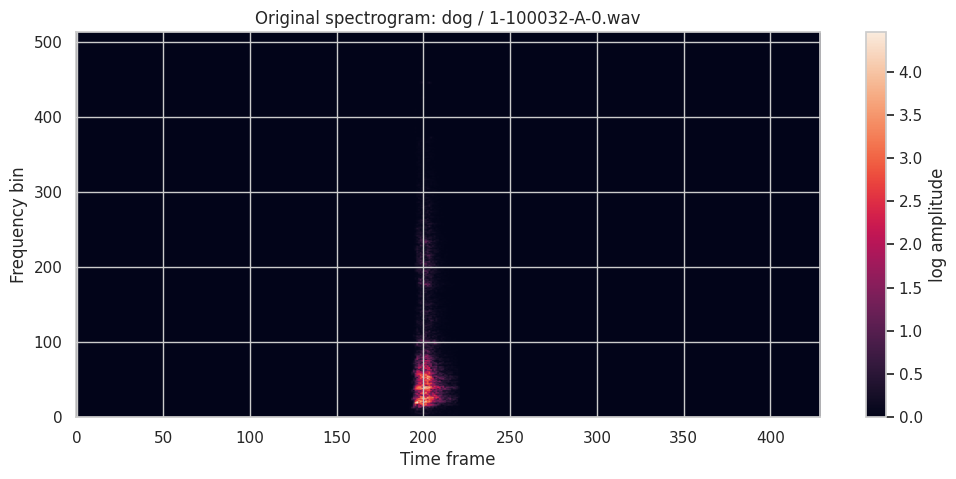

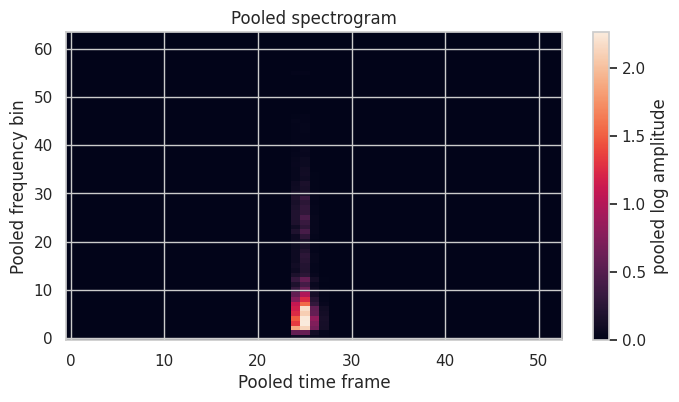

In [6]:
example_file = subset.iloc[0]["filename"]
example_label = subset.iloc[0]["category"]

_, example_spec, example_pooled = extract_features(example_file, pool_size=(8, 8), mode="mean")

plt.figure(figsize=(12, 5))
plt.imshow(example_spec, aspect="auto", origin="lower")
plt.title(f"Original spectrogram: {example_label} / {example_file}")
plt.xlabel("Time frame")
plt.ylabel("Frequency bin")
plt.colorbar(label="log amplitude")
plt.show()

plt.figure(figsize=(8, 4))
plt.imshow(example_pooled, aspect="auto", origin="lower")
plt.title("Pooled spectrogram")
plt.xlabel("Pooled time frame")
plt.ylabel("Pooled frequency bin")
plt.colorbar(label="pooled log amplitude")
plt.show()

## 7. Кластеризація за допомогою SpectralClustering

Оскільки ми маємо два класи звуків, використовуємо `n_clusters=2`. Перед кластеризацією ознаки стандартизуються.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clustering = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=42
)

clusters = clustering.fit_predict(X_scaled)

results = pd.DataFrame({
    "filename": filenames,
    "true_label": y,
    "cluster": clusters
})

display(results.head())
print(pd.crosstab(results["true_label"], results["cluster"]))

,filename,true_label,cluster
0,1-100032-A-0.wav,dog,0
1,1-100038-A-14.wav,chirping_birds,1
2,1-110389-A-0.wav,dog,0
3,1-30226-A-0.wav,dog,0
4,1-30344-A-0.wav,dog,0


cluster          0   1
true_label            
chirping_birds  17  23
dog             37   3


## 8. Оцінка відповідності кластерів реальним класам

Для порівняння використаємо `Adjusted Rand Index`. Значення ближче до 1 означає кращу відповідність кластерів реальним класам.

Adjusted Rand Index: 0.2416


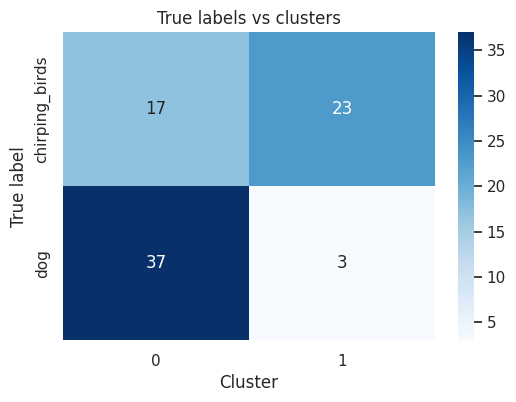

In [8]:
y_numeric = (y == "dog").astype(int)
ari = adjusted_rand_score(y_numeric, clusters)

print("Adjusted Rand Index:", round(ari, 4))

plt.figure(figsize=(6, 4))
sns.heatmap(
    pd.crosstab(results["true_label"], results["cluster"]),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("True labels vs clusters")
plt.xlabel("Cluster")
plt.ylabel("True label")
plt.show()

## 9. Обчислювальні експерименти з різними ступенями стискання

У критеріях прийому згадано експерименти з різними ступенями стискання, тому порівняємо кілька значень `pool_size`. Більший `pool_size` сильніше стискає спектрограму, але може втрачати частину інформації.

,pool_size,feature_vector_length,adjusted_rand_index
0,"(4, 4)",13696,0.241576
1,"(8, 8)",3392,0.241576
2,"(16, 16)",832,0.241576


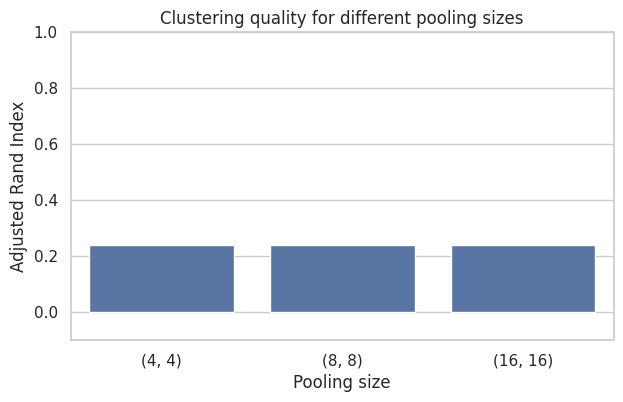

In [9]:
pool_sizes = [(4, 4), (8, 8), (16, 16)]
experiment_results = []

for pool_size in pool_sizes:
    features_exp = []

    for _, row in subset.iterrows():
        vector, _, _ = extract_features(row["filename"], pool_size=pool_size, mode="mean")
        features_exp.append(vector)

    X_exp = np.array(features_exp)
    X_exp_scaled = StandardScaler().fit_transform(X_exp)

    model = SpectralClustering(
        n_clusters=2,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
        random_state=42
    )

    clusters_exp = model.fit_predict(X_exp_scaled)
    ari_exp = adjusted_rand_score(y_numeric, clusters_exp)

    experiment_results.append({
        "pool_size": str(pool_size),
        "feature_vector_length": X_exp.shape[1],
        "adjusted_rand_index": ari_exp
    })

experiment_df = pd.DataFrame(experiment_results)
display(experiment_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=experiment_df, x="pool_size", y="adjusted_rand_index")
plt.title("Clustering quality for different pooling sizes")
plt.xlabel("Pooling size")
plt.ylabel("Adjusted Rand Index")
plt.ylim(-0.1, 1.0)
plt.show()

## 10. Висновки

У цій роботі було застосовано перетворення Фурʼє для побудови спектрограм звукових сигналів із набору ESC-50. Для аналізу були вибрані два класи: `dog` та `chirping_birds`.

Спектрограма дозволяє перейти від сирого аудіосигналу до частотно-часового представлення. Це важливо, тому що різні джерела звуку мають різну частотну структуру. Наприклад, гавкіт собаки та спів птахів можуть відрізнятися за характером частот, тривалістю та розподілом енергії у спектрі.

Pooling зменшив розмір спектрограми та дозволив отримати компактні вектори ознак. Після цього матриці спектрограм були перетворені у вектори за допомогою `.flatten()`, що зробило можливим застосування алгоритму `SpectralClustering`.

Результати кластеризації показують, чи вдалося алгоритму розділити звуки різного походження на різні кластери. Якщо більшість звуків `dog` і `chirping_birds` потрапляють у різні кластери, це означає, що ознаки, отримані зі спектрограм, добре описують відмінності між класами. Якщо частина обʼєктів змішується, це може бути повʼязано з шумом у записах, схожістю окремих частотних компонентів або надто сильним стисканням спектрограми.

Експерименти з різними `pool_size` показують компроміс між розміром ознак і якістю кластеризації. Менше стискання зберігає більше інформації, але створює довші вектори. Більше стискання робить ознаки компактнішими, але може втрачати важливі деталі сигналу.

Отже, перетворення Фурʼє є корисним інструментом для вилучення ознак з аудіоданих. Воно дозволяє представити звук у вигляді спектральних характеристик, які можна використовувати для подальшої кластеризації або класифікації.